In [3]:
from agentic_vnstock import AgenticVNStock
import pandas as pd
import time

client = AgenticVNStock()

tickers = ["VCB", "VHM", "VNM", "MWG", "HPG", "GAS"]

all_data = []

for ticker in tickers:
    try:
        print(f"\n===== {ticker} =====")
        
        df = client.get_stock_historical(ticker, "2018-01-01", "2026-04-21")
        df["ticker"] = ticker
        
        print(df.head())  # in gọn
        
        all_data.append(df)
        
        time.sleep(1)
        
    except Exception as e:
        print(f"Error with {ticker}: {e}")

final_df = pd.concat(all_data, ignore_index=True)


===== VCB =====
         Date   Open   High    Low  Close   Volume ticker
0  2018-01-02  22.83  23.42  22.65  23.25  2801720    VCB
1  2018-01-03  23.46  23.55  23.03  23.21  1843870    VCB
2  2018-01-04  23.12  23.42  22.95  23.42  1990040    VCB
3  2018-01-05  23.29  23.29  22.78  22.83  2045200    VCB
4  2018-01-08  22.83  23.46  22.41  23.42  2071140    VCB

===== VHM =====
         Date   Open   High    Low  Close   Volume ticker
0  2018-05-17  64.42  64.42  64.42  64.42    18000    VHM
1  2018-05-18  64.42  64.42  64.42  64.42        0    VHM
2  2018-05-21  64.42  64.42  64.42  64.42        0    VHM
3  2018-05-22  68.91  68.91  68.91  68.91       20    VHM
4  2018-05-23  66.75  66.75  64.13  64.30  4839580    VHM

===== VNM =====
         Date    Open    High     Low   Close  Volume ticker
0  2018-01-02  100.77  101.19   99.63  100.99  372760    VNM
1  2018-01-03  101.98  102.67  101.28  102.14  557370    VNM
2  2018-01-04  101.77  102.67  101.77  102.57  704350    VNM
3  2018-0

In [4]:
# loại duplicate
final_df = final_df.drop_duplicates(subset=["Date", "ticker"])

# pivot
price_df = final_df.pivot(index="Date", columns="ticker", values="Close")

# sort
price_df = price_df.sort_index()

print(price_df.head())

ticker        GAS   HPG    MWG    VCB  VHM     VNM
Date                                              
2018-01-02  54.26  9.05  30.40  23.25  NaN  100.99
2018-01-03  55.45  9.03  31.00  23.21  NaN  102.14
2018-01-04  58.07  9.14  31.07  23.42  NaN  102.57
2018-01-05  57.16  9.11  30.73  22.83  NaN  101.98
2018-01-08  57.16  9.39  30.24  23.42  NaN  100.28


In [5]:
returns = price_df.pct_change().dropna()

print("\n=== RETURNS ===")
print(returns.head())


=== RETURNS ===
ticker           GAS       HPG       MWG       VCB       VHM       VNM
Date                                                                  
2018-05-18 -0.008631  0.015905  0.027511 -0.004998  0.000000  0.037056
2018-05-21 -0.056362 -0.011742  0.040162 -0.014232  0.000000 -0.029858
2018-05-22 -0.023956 -0.051485 -0.011310 -0.041189  0.069699 -0.024344
2018-05-23  0.069818  0.024008  0.036292  0.019929 -0.066899  0.032708
2018-05-24 -0.000930  0.014271  0.006471 -0.021277  0.038103  0.004382


In [6]:
mean_returns = returns.mean()
volatility = returns.std()

print("\n=== MEAN RETURNS ===")
print(mean_returns)

print("\n=== VOLATILITY ===")
print(volatility)


=== MEAN RETURNS ===
ticker
GAS    0.000320
HPG    0.000749
MWG    0.000886
VCB    0.000605
VHM    0.000658
VNM   -0.000005
dtype: float64

=== VOLATILITY ===
ticker
GAS    0.021370
HPG    0.021153
MWG    0.021603
VCB    0.016831
VHM    0.022277
VNM    0.015505
dtype: float64


In [7]:
corr_matrix = returns.corr()
cov_matrix = returns.cov()

print("\n=== CORRELATION ===")
print(corr_matrix)

print("\n=== COVARIANCE ===")
print(cov_matrix)


=== CORRELATION ===
ticker       GAS       HPG       MWG       VCB       VHM       VNM
ticker                                                            
GAS     1.000000  0.374497  0.412842  0.380204  0.245160  0.323341
HPG     0.374497  1.000000  0.504550  0.430200  0.329760  0.345250
MWG     0.412842  0.504550  1.000000  0.406221  0.368606  0.346529
VCB     0.380204  0.430200  0.406221  1.000000  0.304773  0.397569
VHM     0.245160  0.329760  0.368606  0.304773  1.000000  0.278393
VNM     0.323341  0.345250  0.346529  0.397569  0.278393  1.000000

=== COVARIANCE ===
ticker       GAS       HPG       MWG       VCB       VHM       VNM
ticker                                                            
GAS     0.000457  0.000169  0.000191  0.000137  0.000117  0.000107
HPG     0.000169  0.000447  0.000231  0.000153  0.000155  0.000113
MWG     0.000191  0.000231  0.000467  0.000148  0.000177  0.000116
VCB     0.000137  0.000153  0.000148  0.000283  0.000114  0.000104
VHM     0.000117  0.0

In [8]:
import numpy as np

num_assets = len(returns.columns)
weights = np.ones(num_assets) / num_assets

portfolio_return = np.dot(weights, mean_returns)
portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

print("\n=== PORTFOLIO ===")
print("Weights:", weights)
print("Return:", portfolio_return)
print("Risk:", portfolio_vol)


=== PORTFOLIO ===
Weights: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Return: 0.0005354955201113376
Risk: 0.013588234384836076


In [9]:
portfolio_returns = returns.dot(weights)

VaR_95 = np.percentile(portfolio_returns, 5)

print("\n=== VaR 95% ===")
print(VaR_95)


=== VaR 95% ===
-0.02064274718982123


In [10]:
risk_free_rate = 0.03 / 252

sharpe = (portfolio_return - risk_free_rate) / portfolio_vol

print("\n=== SHARPE ===")
print(sharpe)


=== SHARPE ===
0.03064768308150893


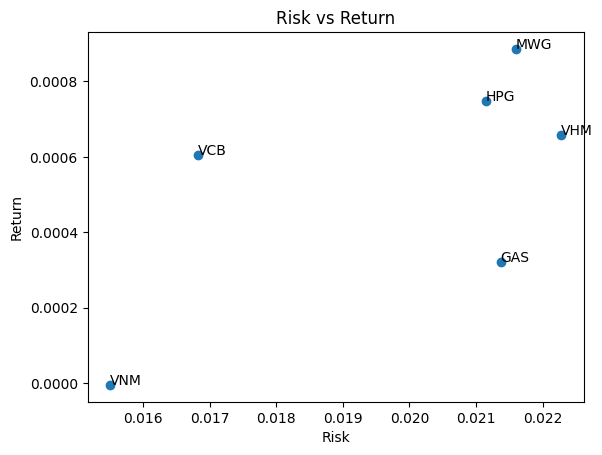

In [11]:
plt.scatter(volatility, mean_returns)

for ticker in mean_returns.index:
    plt.annotate(ticker, (volatility[ticker], mean_returns[ticker]))

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

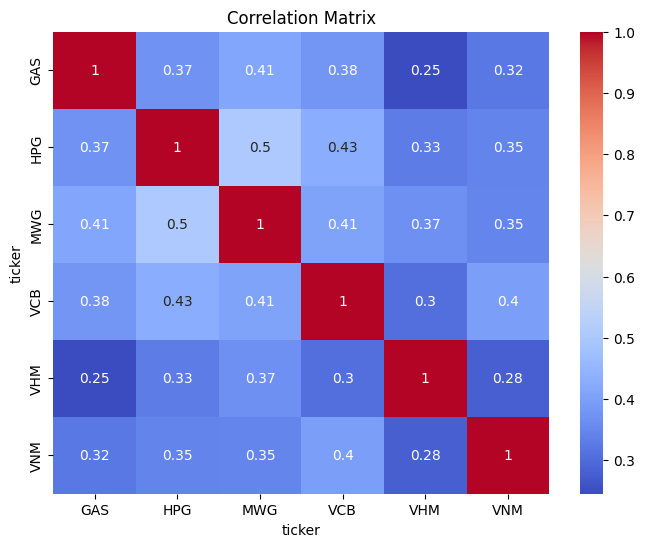

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

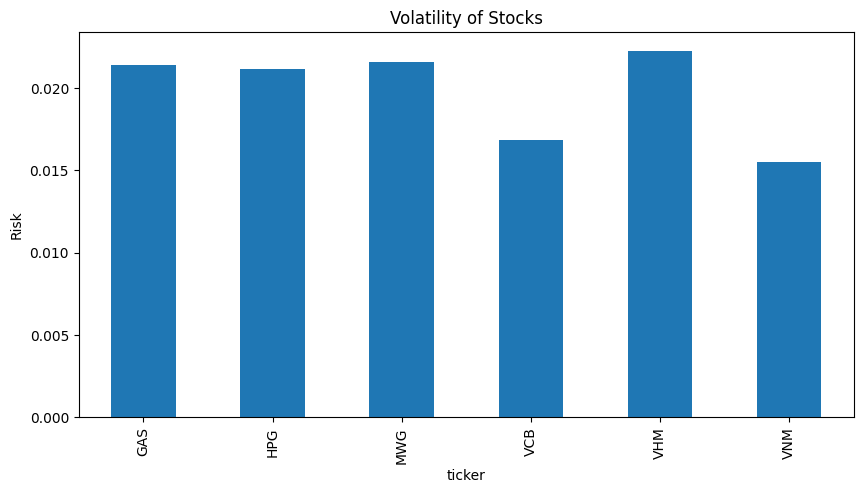

In [13]:
volatility.plot(kind='bar', figsize=(10,5))
plt.title("Volatility of Stocks")
plt.ylabel("Risk")
plt.show()

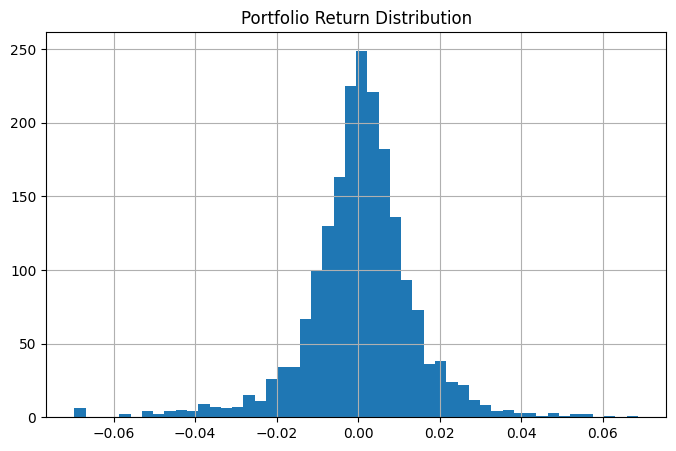

In [14]:
portfolio_returns.hist(bins=50, figsize=(8,5))
plt.title("Portfolio Return Distribution")
plt.show()

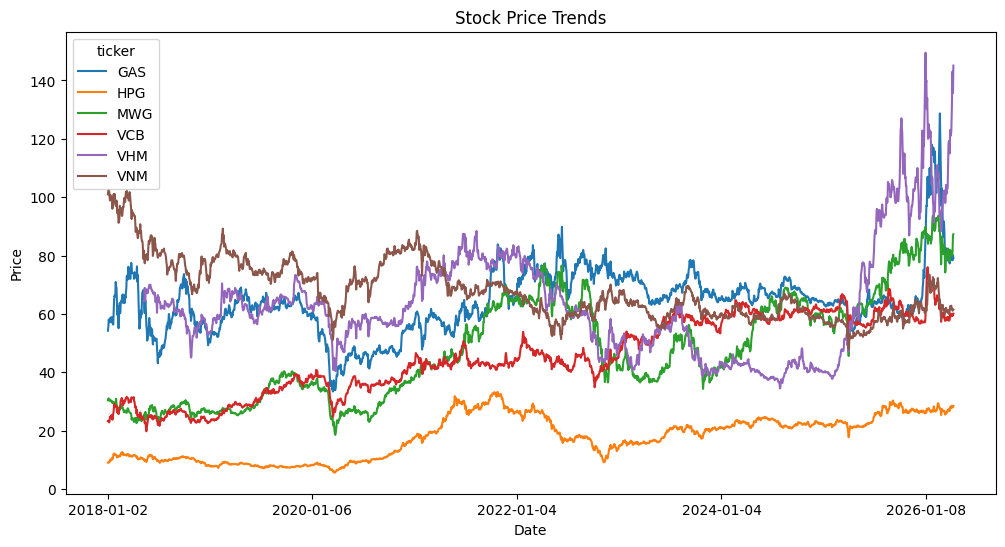

In [15]:
import matplotlib.pyplot as plt

price_df.plot(figsize=(12,6))
plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [16]:
# nếu đã có price_df
returns = price_df.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print(mean_returns.head())

ticker
GAS    0.000320
HPG    0.000749
MWG    0.000886
VCB    0.000605
VHM    0.000658
dtype: float64


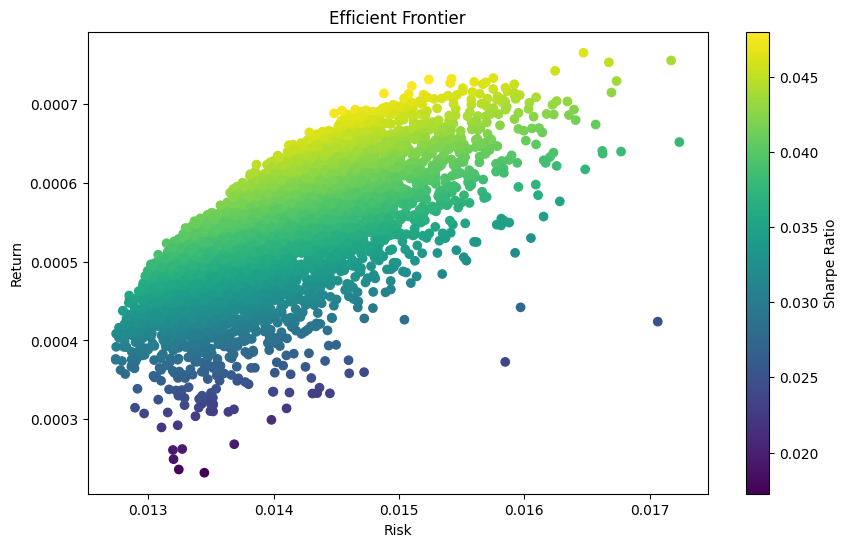

In [17]:
import numpy as np
import matplotlib.pyplot as plt

num_portfolios = 5000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)
    
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0,i] = portfolio_vol
    results[1,i] = portfolio_return
    results[2,i] = portfolio_return / portfolio_vol  # Sharpe

# vẽ
plt.figure(figsize=(10,6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()

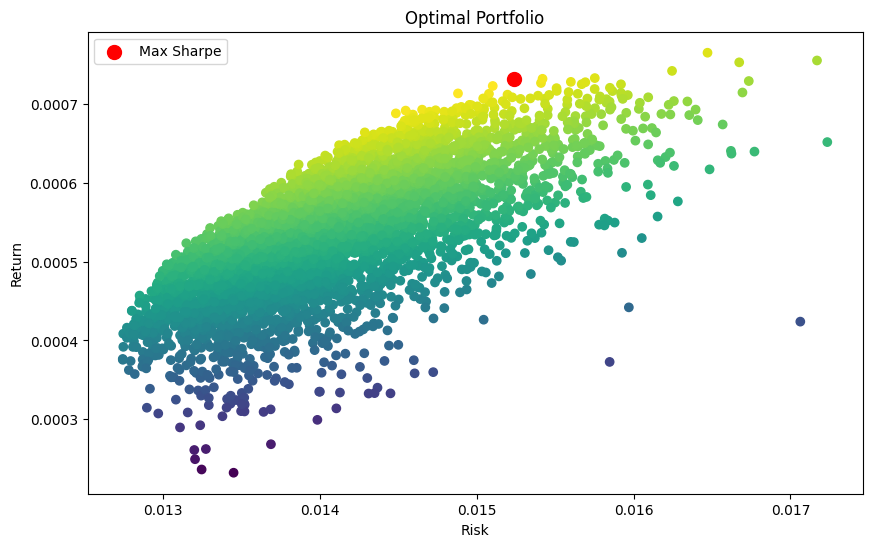

In [18]:
max_sharpe_idx = np.argmax(results[2])
max_vol = results[0, max_sharpe_idx]
max_ret = results[1, max_sharpe_idx]

plt.figure(figsize=(10,6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.scatter(max_vol, max_ret, color='red', s=100, label='Max Sharpe')
plt.legend()
plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Optimal Portfolio')
plt.show()

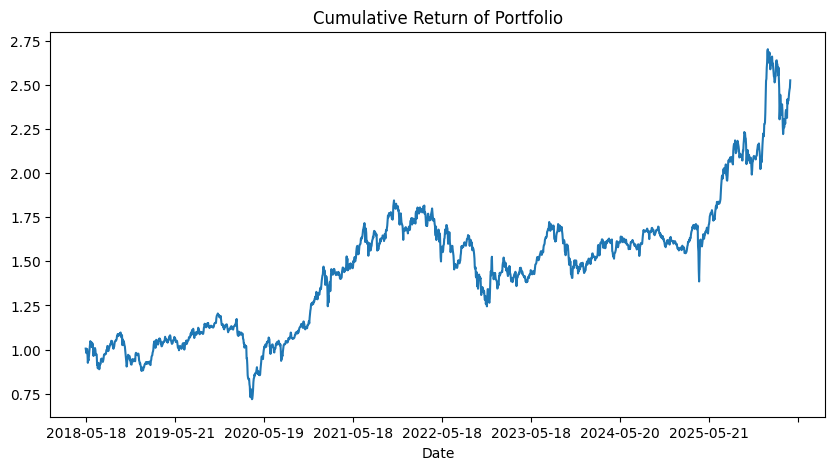

In [19]:
portfolio_returns = returns.dot(weights)

cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.plot(figsize=(10,5))
plt.title("Cumulative Return of Portfolio")
plt.show()

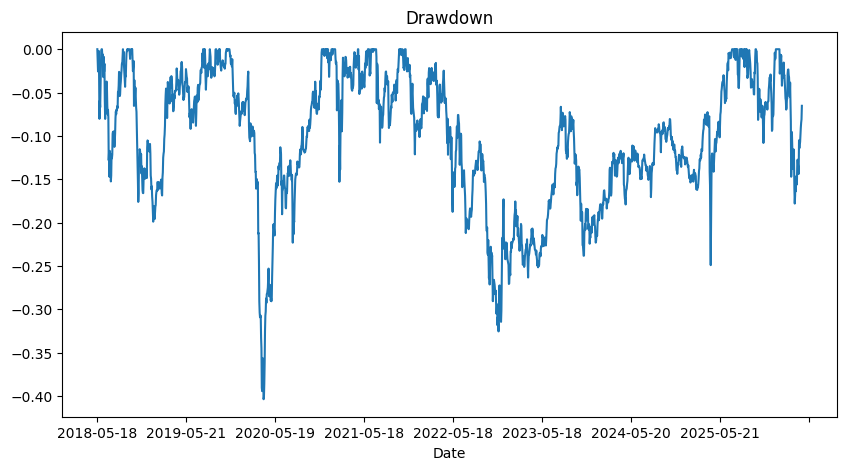

In [20]:
cum = (1 + portfolio_returns).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

drawdown.plot(figsize=(10,5))
plt.title("Drawdown")
plt.show()

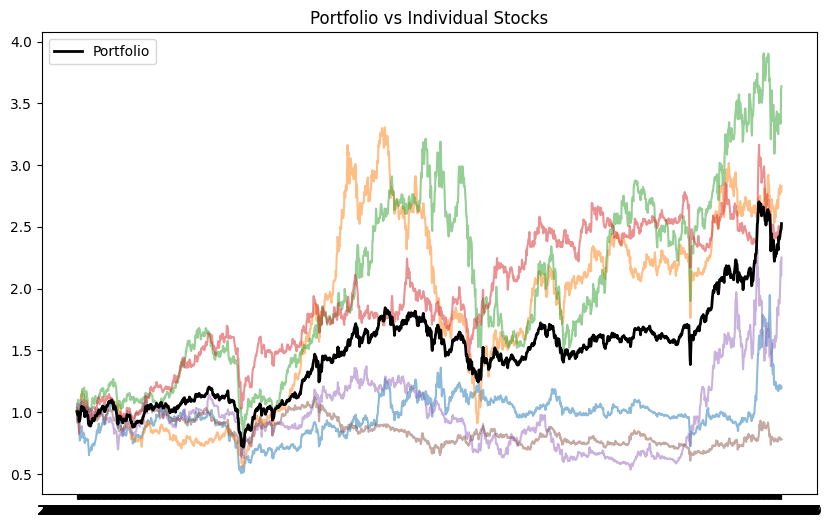

In [21]:
cumulative_stock = (1 + returns).cumprod()

plt.figure(figsize=(10,6))
for col in cumulative_stock.columns:
    plt.plot(cumulative_stock.index, cumulative_stock[col], alpha=0.5)

plt.plot(cumulative_returns, color='black', linewidth=2, label='Portfolio')
plt.legend()
plt.title("Portfolio vs Individual Stocks")
plt.show()